# **08. Model Evaluation**

#### **Introduction**

This notebook evaluates a predictive model developed using the **Bank Telemarketing dataset** containing 45,211 customer records. The model's performance is evaluated using **Gain, Lift, and Decile Analysis** to determine how effectively it identifies customers who are more likely to subscribe to a term deposit. The analysis helps in ranking customers based on their predicted response and identifying the most promising customer segments for targeted marketing.


### **Project Structure**

**1. Model Calibration**
    
- Calibration plot → Check whether predicted probabilities are reliable.
- Brier score → Summarize probability-quality in one number.

**2. Decile Analysis** → Divide customers into 10 groups based on predicted probability/score and compare actual response rates.
* Decile response rate
* Number of responders
* Cumulative responders

**3. Lift Analysis** → Show how much better each decile performs compared with the overall response rate.
* Lift by decile
* Lift chart

**4. Gain Analysis** → Show the cumulative percentage of responders captured as you move down the ranked customer list.
* Cumulative gain 
* Gain chart

**5. Uncertainty Analysis** → Add statistical uncertainty to your key decile/lift/gain/business metrics.
* Bootstrap confidence intervals for response rate/lift/gain

**6. Business Impact** → Translate the model's targeting performance into business value.
* Baseline strategy
* Top-10% strategy
* Net profit
* Profit per contacted customer
* Profit-efficiency lift
* ROI comparison

---

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
import time
from pathlib import Path
import pickle
import joblib

In [3]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, Markdown

def display_md(string):
    display(Markdown(string))
    

In [4]:
# Define path for dataframe file
parent_path = Path.cwd().parent
data_file = parent_path.joinpath("data", "interim")
files = []
for file in data_file.rglob("*"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file, end="\n\n")


.gitkeep
0   e:\Bank-Telemarketing\data\interim\.gitkeep

xgb_prediction.csv
1   e:\Bank-Telemarketing\data\interim\xgb_prediction.csv



In [5]:
display_md("**Loading Dataframe of  Actual & Predicted Values...**")
try:
    df = pd.read_csv(files[1], sep=',')
    display(df.head())
except Exception as e:
    print(f"Data Loading Error : {e}")
    

**Loading Dataframe of  Actual & Predicted Values...**

,actual_xgb,probability_xgb
0,0,0.009562
1,0,0.888495
2,0,0.082937
3,0,0.953316
4,0,0.512221


In [22]:
print(round(df['actual_xgb'].mean()*100, 1))
print(round(df['probability_xgb'].mean()*100), 1)

11.7
25 1


## **1. Calibration Analysis**

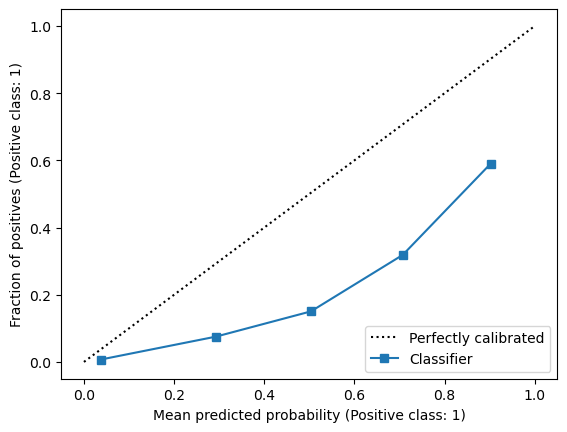

In [6]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(
    df['actual_xgb'],
    df['probability_xgb'],
    #n_bins=10,
    #strategy='quantile'
)

plt.show()


In [17]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(df['actual_xgb'], df['probability_xgb'])

print(f"Brier Score: {brier:.2f}")


Brier Score: 0.10


## **1. Decile Analysis**

In [43]:
# First, sort customers by their predicted probability from highest to lowest

df_result = df.sort_values(
    by='probability_xgb',
    ascending=False
).reset_index(drop=True)

# Create 10 equal-sized groups
df_result['decile'] = pd.qcut(
    df_result['probability_xgb'],
    q=10,
    labels=False,
    duplicates='drop'
)

# Make highest probability decile = 1
df_result['decile'] = 10 - df_result['decile']

# Now calculate decile-level performance
decile_table = df_result.groupby('decile').agg(
    customers = ('actual_xgb', 'count'),
    responders = ('actual_xgb', 'sum'),
    response_rate = ('actual_xgb', 'mean'),
    predicted_prob = ('probability_xgb', 'mean')
).reset_index()

decile_table['response_rate'] = decile_table['response_rate'].mul(100)
decile_table['predicted_prob'] = decile_table['predicted_prob'].mul(100)

# bootstrap the response rate
# for each bootstrap iteration, we resample customers within each decile, with replacement,and calculate the response rate again
n_bootstrap = 500
rng = np.random.default_rng(42) # random seed

bootstrap_rates = np.zeros((n_bootstrap, 10))

for b in range(n_bootstrap):
    for d in range(1, 11):
        # customers belongs to the original decile
        decile_data = df_result.loc[df_result['decile'] == d, 'actual_xgb'].values
        # bootstrap sample
        sample = rng.choice(
            decile_data,
            size=len(decile_data),
            replace=True
        )
        # response rate
        bootstrap_rates[b, d-1] = sample.mean()

# Calculate 95% CI
ci_lower = np.percentile(
    bootstrap_rates,
    q=2.5,
    axis=0
)

ci_upper = np.percentile(
    bootstrap_rates,
    q=97.5,
    axis=0
)

decile_table['ci_lower'] = ci_lower * 100
decile_table['ci_upper'] = ci_upper * 100


decile_table['95% CI'] = (
    (decile_table['ci_lower']).round(1).astype(str)
    + "—" +
    (decile_table['ci_upper']).round(1).astype(str)
    + "%"
)

# ============================================================
# Display table
# ============================================================

decile_df = (
    decile_table.iloc[:, [0, 1, 2, 3, 4, 7]]
    .style
    .format({
        "customers": "{:,.0f}",
        "responders": "{:,.0f}",
        "response_rate": "{:.1f}%",
        "predicted_prob": "{:.1f}%"
       # "ci_lower": "{:.1f}%",
       # "ci_upper": "{:.1f}%"
    })
    .hide(axis='index')
)

display(decile_df)
display_md("**Decile 1** has an observed response rate of 60.8%, with a 95% bootstrap CI of [58.3%, 63.5%].")


decile,customers,responders,response_rate,predicted_prob,95% CI
1,"1,492",907,60.8%,91.8%,58.3—63.5%
2,"1,492",526,35.3%,72.8%,32.9—37.6%
3,"1,492",193,12.9%,44.8%,11.4—14.8%
4,"1,492",73,4.9%,21.2%,3.8—5.8%
5,"1,491",27,1.8%,8.9%,1.2—2.5%
6,"1,492",11,0.7%,4.0%,0.3—1.2%
7,"1,492",4,0.3%,2.0%,0.0—0.6%
8,"1,492",1,0.1%,1.0%,0.0—0.2%
9,"1,492",2,0.1%,0.4%,0.0—0.3%
10,"1,492",1,0.1%,0.1%,0.0—0.2%


**Decile 1** has an observed response rate of 60.8%, with a 95% bootstrap CI of [58.3%, 63.5%].

## **2. Gain Analysis**

Gain tells us what percentage of all actual responders are captured when we target the highest-ranked customers.

decile,customers,responders,response_rate,predicted_prob,cumulative_customers,cumulative_responders,cumulative_customer_pct,cumulative_gain
1,"1,492",907,60.8%,91.828748,"1,492",907,10%,52.0%
2,"1,492",526,35.3%,72.808157,"2,984","1,433",20%,82.1%
3,"1,492",193,12.9%,44.804833,"4,476","1,626",30%,93.2%
4,"1,492",73,4.9%,21.155518,"5,968","1,699",40%,97.4%
5,"1,491",27,1.8%,8.864647,"7,459","1,726",50%,98.9%
6,"1,492",11,0.7%,3.981196,"8,951","1,737",60%,99.5%
7,"1,492",4,0.3%,2.027543,"10,443","1,741",70%,99.8%
8,"1,492",1,0.1%,0.976430,"11,935","1,742",80%,99.8%
9,"1,492",2,0.1%,0.395223,"13,427","1,744",90%,99.9%
10,"1,492",1,0.1%,0.105623,"14,919","1,745",100%,100.0%


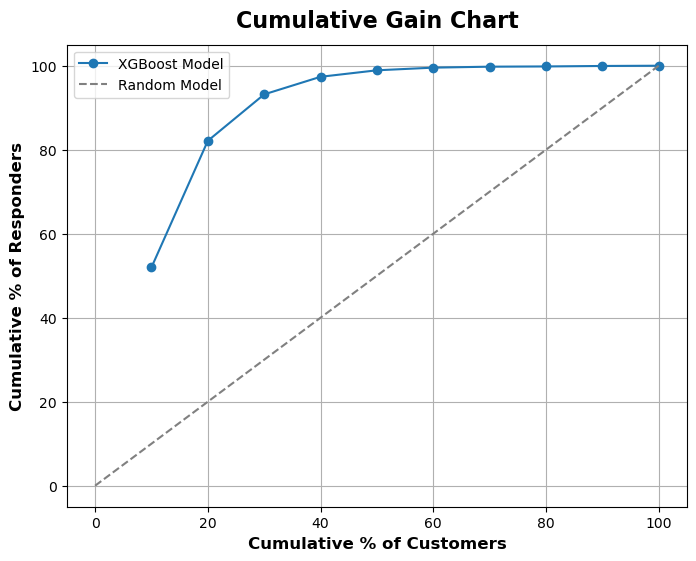

First 2 deciles contain 82.1% of all responders, the model has a 82.1% cumulative gain at 20% of the population


In [10]:
total_responders = df_result['actual_xgb'].sum()

decile_table['cumulative_customers'] = decile_table['customers'].cumsum()

decile_table['cumulative_responders'] = decile_table['responders'].cumsum()

decile_table["cumulative_customer_pct"] = (
    decile_table["cumulative_customers"]
    / len(df) * 100
)

decile_table["cumulative_gain"] = (
    decile_table["cumulative_responders"]
    / total_responders * 100
)

gain_table = decile_table.style.format({"customers":"{:,.0f}", "response_rate":"{:.1f}%",
                                        'cumulative_customers':"{:,.0f}", 'cumulative_responders':'{:,.0f}',
                                        'cumulative_customer_pct': '{:.0f}%', 'cumulative_gain' : '{:.1f}%'}).hide(axis='index')
display(gain_table)

# Gain Chart
plt.figure(figsize=(8, 6))

plt.plot(
    decile_table["cumulative_customer_pct"],
    decile_table["cumulative_gain"],
    marker="o",
    label="XGBoost Model"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="gray",
    label="Random Model"
)

plt.xlabel("Cumulative % of Customers", fontsize=12, fontweight='bold')
plt.ylabel("Cumulative % of Responders", fontsize=12, fontweight='bold')
plt.title("Cumulative Gain Chart", fontsize=16, fontweight='bold', y=1.02)
plt.legend()
plt.grid(True)
plt.show()

print("First 2 deciles contain 82.1% of all responders, the model has a 82.1% cumulative gain at 20% of the population")


## **3. Lift Analysis**

Lift compares the model's response rate with the response rate obtained by randomly selecting customers.

decile,customers,responders,response_rate,predicted_prob,cumulative_customers,cumulative_responders,cumulative_customer_pct,cumulative_gain,lift,cumulative_lift
1,1492,907,60.790885,91.828748,1492,907,10%,52.0%,5.2,5.2
2,1492,526,35.254692,72.808157,2984,1433,20%,82.1%,3.0,4.1
3,1492,193,12.935657,44.804833,4476,1626,30%,93.2%,1.1,3.1
4,1492,73,4.892761,21.155518,5968,1699,40%,97.4%,0.4,2.4
5,1491,27,1.810865,8.864647,7459,1726,50%,98.9%,0.2,2.0
6,1492,11,0.737265,3.981196,8951,1737,60%,99.5%,0.1,1.7
7,1492,4,0.268097,2.027543,10443,1741,70%,99.8%,0.0,1.4
8,1492,1,0.067024,0.976430,11935,1742,80%,99.8%,0.0,1.2
9,1492,2,0.134048,0.395223,13427,1744,90%,99.9%,0.0,1.1
10,1492,1,0.067024,0.105623,14919,1745,100%,100.0%,0.0,1.0


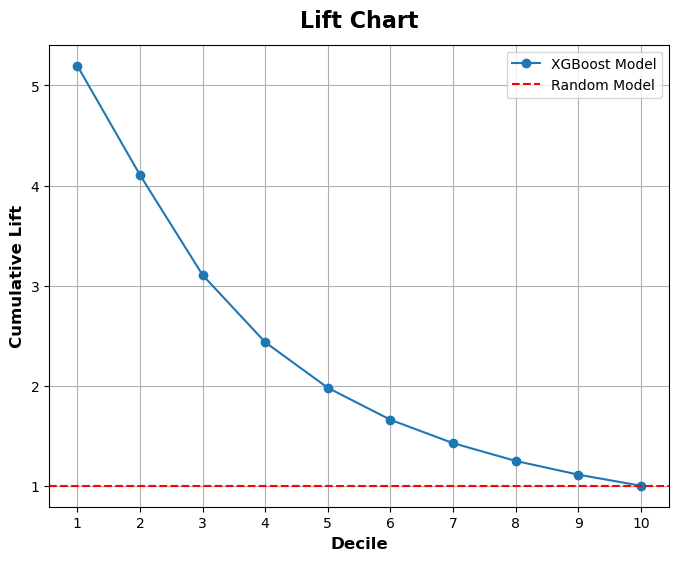

**Decile 1 has a lift of 5.2, it means: Customers in the top 10% ranked by the model are 5.2 times more likely to subscribe than customers selected randomly.**

In [11]:
overall_response_rate = (df_result['actual_xgb'].mean()*100)

decile_table["lift"] = (
    decile_table["response_rate"]
    / overall_response_rate
)

decile_table["cumulative_lift"] = (
    decile_table["cumulative_gain"]
    / decile_table["cumulative_customer_pct"]
)
# both lift and cumulative_lift are same
lift_table = decile_table.style.format({
    'cumulative_customer_pct': '{:.0f}%', 'cumulative_gain' : '{:.1f}%',
    'lift':'{:.1f}', 'cumulative_lift':'{:.1f}'
    }).hide(axis='index')
display(lift_table) 

# Lift Chart
print()
plt.figure(figsize=(8, 6))

plt.plot(
    decile_table["decile"],
    decile_table["cumulative_lift"],
    marker="o",
    label="XGBoost Model"
)

plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Decile", fontsize=12, fontweight='bold')
plt.ylabel("Cumulative Lift", fontsize=12, fontweight='bold')
plt.title("Lift Chart", fontsize=16, fontweight='bold', y=1.02)
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

display_md("**Decile 1 has a lift of 5.2, it means: Customers in the top 10% ranked by the model are 5.2 times more likely to subscribe than customers selected randomly.**")



## **4. Baseline vs Top-10% ROI**

The improvement from targeting the top 10% is

__Efficiency Lift = Profit Per Customer (Top 10%) / Profit Per Customer (baseline)__

where, Profit Per Customer = Net Profit / Total Customers

In [12]:
# Business assumptions
revenue_per_conversion = 200
cost_per_contact = 10

# -----------------------------
# Overall Campaign
# -----------------------------

total_customers = len(df_result)

overall_conversion_rate = df_result["actual_xgb"].mean()

overall_conversions = (
    total_customers * overall_conversion_rate
)

overall_revenue = (
    overall_conversions * revenue_per_conversion
)

overall_cost = (
    total_customers * cost_per_contact
)

overall_net_profit = (
    overall_revenue - overall_cost
)

overall_roi = (
    (overall_revenue - overall_cost)
    / overall_cost
) * 100

# Profit Efficiency: compare the net profit generated per customer contacted
overall_profit_efficiency = (
    overall_net_profit / (total_customers)
)

# -----------------------------
# Top 10% Campaign
# -----------------------------

top_10_customers = (
    decile_table.loc[
        decile_table['decile']==1,
        'customers'
    ].iloc[0]
)

# Conversion rate of Decile 1
top_10_conversion_rate = (
    decile_table.loc[
        decile_table["decile"] == 1,
        "response_rate"
    ].iloc[0]/100
)

top_10_conversions = (
    decile_table.loc[
        decile_table['decile']==1,
        'responders'
    ].iloc[0]
)

top_10_revenue = (
    top_10_conversions * revenue_per_conversion
)

top_10_cost = (
    top_10_customers * cost_per_contact
)

top_10_net_profit = (
    top_10_revenue - top_10_cost
)

top_10_profit_efficiency = (
    top_10_net_profit / (top_10_customers)
)

top_10_roi = (
    (top_10_revenue - top_10_cost)
    / top_10_cost
) * 100

efficiency_lift = (
    top_10_profit_efficiency / overall_profit_efficiency
)

# -----------------------------
# Comparison
# -----------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Customers Contacted",
        "Conversion Rate",
        "Expected Conversions",
        "Revenue",
        "Campaign Cost",
        "Net Profit",
        "Net Profit Per Customers",
        "Efficiency Lift",
        "ROI (%)"
    ],
    
    "Overall Campaign": [
        total_customers,
        overall_conversion_rate * 100,
        overall_conversions,
        overall_revenue,
        overall_cost,
        overall_net_profit,
        overall_profit_efficiency,
        '—',
        overall_roi
    ],
    
    "Top 10% Campaign": [
        top_10_customers,
        top_10_conversion_rate * 100,
        top_10_conversions,
        top_10_revenue,
        top_10_cost,
        top_10_net_profit,
        top_10_profit_efficiency,
        efficiency_lift,
        top_10_roi
    ]
})
pd.set_option('display.float_format', "{:.1f}".format)
display(comparison)
display_md("**Top-10% targeting strategy generates approximately 8.3 x higher profit per contacted customer than the baseline strategy.**")


,Metric,Overall Campaign,Top 10% Campaign
0,Customers Contacted,14919,1492.0
1,Conversion Rate,11.7,60.8
2,Expected Conversions,1745.0,907.0
3,Revenue,349000.0,181400.0
4,Campaign Cost,149190,14920.0
5,Net Profit,199810.0,166480.0
6,Net Profit Per Customers,13.4,111.6
7,Efficiency Lift,—,8.3
8,ROI (%),133.9,1115.8


**Top-10% targeting strategy generates approximately 8.3 x higher profit per contacted customer than the baseline strategy.**

| Metric | Call all 14,919 Leads | Call Top 10% ~ 1,492 Leads |
|--------|------------------:|------------------:|
| Total Customers Contacted | 14,919 | 1,492 |
| Conversion Rate | 11.7% (baseline) | 60.8% |
| Successful Subscriptions | 1,745 | 907 |
| Revenue per Subscription | $200 | $200 |
| Total Revenue | $3,49,000 | $1,81,400 |
| Campaign Cost (@ $10/contact) | $1,49,190 | $14,920 |
| Net Profit | $1,99,810 | $1,66,480 |
| Profit Per Customer | 13.4 | 111.6 |
| ROI | 133.9% | 1115.8% |
| ROI Improvement | — | +981.9 percentage points |
| Cost Reduction vs. Calling All | — | ~ 90% fewer calls |
| Efficiency Lift | — | 8.3 x higher profit per contacted customer |


## **5. Project Highlights**

| Analysis             | Main question                                            |
| -------------------- | -------------------------------------------------------- |
| **Decile analysis**  | Does the model rank customers effectively?               |
| **Gain**             | How many responders do I capture by targeting X%?        |
| **Lift**             | How much better is targeting X% than random?             |
| **Baseline vs Top-10% ROI**             | How many times more profitable is targeting the top 10% compared with the baseline strategy?             |
| **Calibration plot** | Are the predicted probabilities numerically trustworthy? |
| **Brier score**      | How accurate are the predicted probabilities overall?    |
| **Bootstrap CI**     | How certain are my decile/lift estimates?                |
